# MainSystem

Example notebook `python/Notebooks/reference/mainSystem.ipynb`: the examples of the `MainSystem`, its extensions, its
`systemData` and the `GeneralContact` in the reference manual (the definitions `pybindMainSystem.py`,
`pybindSystemData.py` and `pybindGeneralContact.py`); each example is tagged `part-<name>` and shown where the manual
explains it.

## MainSystem

In [1]:
import exudyn as exu
SC = exu.SystemContainer()
mbs = SC.AddSystem()

## Extensions: create

In [2]:
import exudyn as exu
from exudyn.utilities import *
#alternative: import exudyn.misc.mainSystemExtensions
SC = exu.SystemContainer()
mbs = SC.AddSystem()
#
#create rigid body
b1=mbs.CreateRigidBody(inertia = InertiaCuboid(density=5000, sideLengths=[0.1,0.1,1]),
                       referencePosition = [1,0,0],
                       gravity = [0,0,-9.81])

## Extensions: general

A mass point on a spring-damper with a sensor, which the example needs:

In [3]:
SC = exu.SystemContainer()
mbs = SC.AddSystem()
oGround = mbs.CreateGround()
oMass = mbs.CreateMassPoint(referencePosition=[1,0,0], mass=1)
mbs.CreateSpringDamper(itemNumbers=[oGround, oMass], stiffness=100, damping=1)
sensorNumber = mbs.AddSensor(SensorBody(bodyNumber=oMass, storeInternal=True,
                                        outputVariableType=exu.OutputVariableType.Position))
mbs.Assemble()

ODE2 coordinates          = 3
total constraints         = 0
redundant constraints     = 0
pure algebraic constraints= 0
degree of freedom         = 3


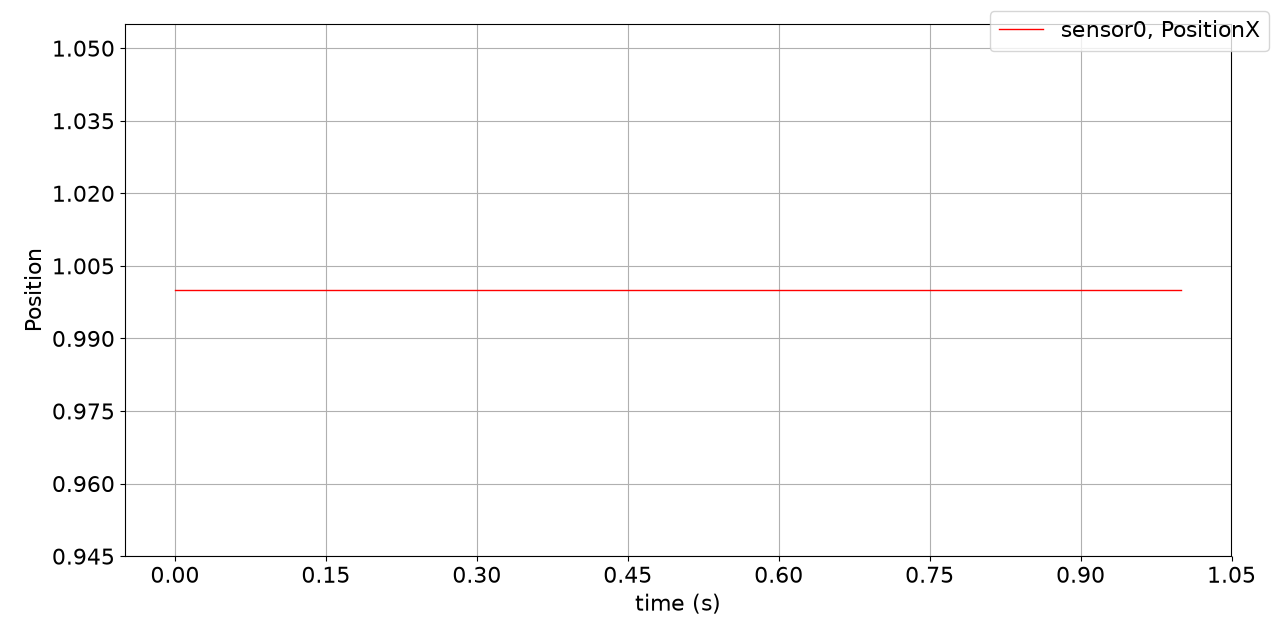

In [4]:
#this example sketches the usage
#for complete examples see Examples/ or TestModels/ folders
#create some multibody system (mbs) first:
# ...
#
#compute system degree of freedom:
mbs.ComputeSystemDegreeOfFreedom(verbose=True)
#
#call solver function directly from mbs:
mbs.SolveDynamic(exu.SimulationSettings())
#
#plot sensor directly from mbs:
mbs.PlotSensor(sensorNumber, components=[0])

## Node

In [5]:
import exudyn as exu               #EXUDYN package including C++ core part
from exudyn.itemInterface import * #conversion of data to exudyn dictionaries
SC = exu.SystemContainer()         #container of systems
mbs = SC.AddSystem()               #add a new system to work with
nMP = mbs.AddNode(NodePoint2D(referenceCoordinates=[0,0]))

## Object

In [6]:
import exudyn as exu               #EXUDYN package including C++ core part
from exudyn.itemInterface import * #conversion of data to exudyn dictionaries
SC = exu.SystemContainer()         #container of systems
mbs = SC.AddSystem()               #add a new system to work with
nMP = mbs.AddNode(NodePoint2D(referenceCoordinates=[0,0]))
oMP = mbs.AddObject(ObjectMassPoint2D(mass=10, nodeNumber=nMP ))

## Marker

In [7]:
import exudyn as exu               #EXUDYN package including C++ core part
from exudyn.itemInterface import * #conversion of data to exudyn dictionaries
SC = exu.SystemContainer()         #container of systems
mbs = SC.AddSystem()               #add a new system to work with
nMP = mbs.AddNode(NodePoint2D(referenceCoordinates=[0,0]))
mbs.AddObject(ObjectMassPoint2D(mass=10, nodeNumber=nMP ))
mMP = mbs.AddMarker(MarkerNodePosition(nodeNumber = nMP))

## Load

In [8]:
import exudyn as exu               #EXUDYN package including C++ core part
from exudyn.itemInterface import * #conversion of data to exudyn dictionaries
SC = exu.SystemContainer()         #container of systems
mbs = SC.AddSystem()               #add a new system to work with
nMP = mbs.AddNode(NodePoint2D(referenceCoordinates=[0,0]))
mbs.AddObject(ObjectMassPoint2D(mass=10, nodeNumber=nMP ))
mMP = mbs.AddMarker(MarkerNodePosition(nodeNumber = nMP))
lMP = mbs.AddLoad(Force(markerNumber = mMP, loadVector=[0.001,0,0]))

## Sensor

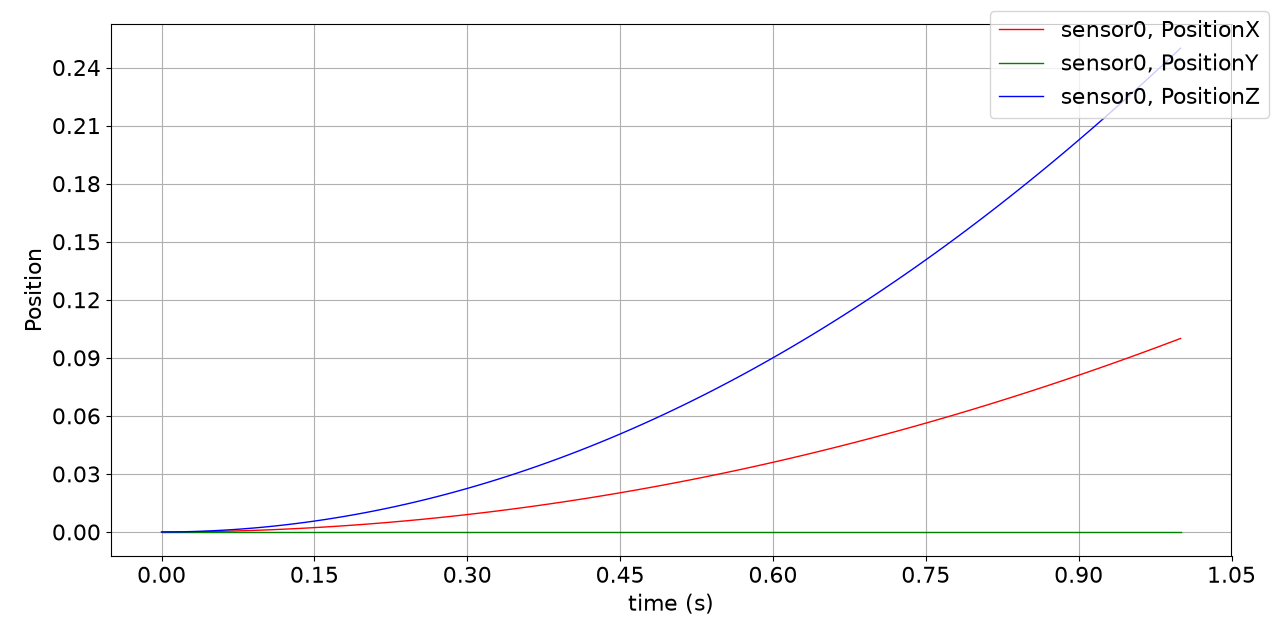

In [9]:
import exudyn as exu               #EXUDYN package including C++ core part
from exudyn.itemInterface import * #conversion of data to exudyn dictionaries
SC = exu.SystemContainer()         #container of systems
mbs = SC.AddSystem()               #add a new system to work with
nMP = mbs.AddNode(NodePoint(referenceCoordinates=[0,0,0]))
mbs.AddObject(ObjectMassPoint(mass=10, nodeNumber=nMP ))
mMP = mbs.AddMarker(MarkerNodePosition(nodeNumber = nMP))
mbs.AddLoad(Force(markerNumber = mMP, loadVector=[2,0,5]))
sMP = mbs.AddSensor(SensorNode(nodeNumber=nMP, storeInternal=True,
                               outputVariableType=exu.OutputVariableType.Position))
mbs.Assemble()
mbs.SolveDynamic(exu.SimulationSettings())
from exudyn.plot import PlotSensor
PlotSensor(mbs, sMP, components=[0,1,2])

## SystemData

In [10]:
import exudyn as exu               #EXUDYN package including C++ core part
from exudyn.itemInterface import * #conversion of data to exudyn dictionaries
SC = exu.SystemContainer()         #container of systems
mbs = SC.AddSystem()               #add a new system to work with
nMP = mbs.AddNode(NodePoint(referenceCoordinates=[0,0,0]))
mbs.AddObject(ObjectMassPoint(mass=10, nodeNumber=nMP ))
mMP = mbs.AddMarker(MarkerNodePosition(nodeNumber = nMP))
mbs.AddLoad(Force(markerNumber = mMP, loadVector=[2,0,5]))
mbs.Assemble()
mbs.SolveDynamic(exu.SimulationSettings())

#obtain current ODE2 system vector including reference values:
uTotal = mbs.systemData.GetODE2CoordinatesTotal()

#obtain current ODE2 system vector without reference values
#  (e.g., after static simulation finished):
u = mbs.systemData.GetODE2Coordinates()
#set initial ODE2 vector for next simulation (only coordinates!):
mbs.systemData.SetODE2Coordinates(coordinates=u,
               configuration=exu.ConfigurationType.Initial)

#faster access with reference access (copy=False):
uReference = mbs.systemData.GetODE2Coordinates(copy=False)
u2 = uReference[2]
#we can also modify data, but this may be dangerous!
uReference[2] += 1
print('u2 =', u2, ', now:', mbs.systemData.GetODE2Coordinates()[2])
#NOTE: reference access is possible throughout simulation and may
#      allow faster user functions, but is potentially dangerous
#      to erroneous behavior: for safety, compare with copy=True results!

#print detailed information on items:
mbs.systemData.Info()
#print LTG lists for objects and loads:
mbs.systemData.InfoLTG()

u2 = 0.24999999999999897 , now: 1.249999999999999
node0:
    {'nodeType': 'Point', 'referenceCoordinates': array([0., 0., 0.]), 'initialCoordinates': array([0., 0., 0.]), 'initialVelocities': array([0., 0., 0.]), 'name': 'node0', 'Vshow': True, 'VdrawSize': -1.0, 'Vcolor': [-1.0, -1.0, -1.0, -1.0]}
object0:
    {'objectType': 'MassPoint', 'mass': 10.0, 'nodeNumber': 0, 'name': 'object0', 'Vshow': True, 'VgraphicsData': [{'graphicsData': '<not requested>'}]}
marker0:
    {'markerType': 'NodePosition', 'nodeNumber': 0, 'name': 'marker0', 'Vshow': True}
load0:
    {'loadType': 'ForceVector', 'markerNumber': 0, 'loadVector': array([2., 0., 5.]), 'bodyFixed': False, 'loadVectorUserFunction': 0, 'name': 'load0', 'Vshow': True}
object 0 ODE2 LTG=[0,1,2]
object 0 ODE1 LTG=[]
object 0 AE LTG  =[]
object 0 Data LTG=[]


## GeneralContact

A mass point with a marker, which the example needs:

In [11]:
import numpy as np
from exudyn.utilities import *
SC = exu.SystemContainer()
mbs = SC.AddSystem()
oMass = mbs.CreateMassPoint(referencePosition=[0,0,0.1], mass=1, gravity=[0,0,-9.81])
marker = mbs.AddMarker(MarkerBodyPosition(bodyNumber=oMass))

In [12]:
#...
#code snippet, must be placed anywhere before mbs.Assemble()
#Add GeneralContact to mbs:
gContact = mbs.AddGeneralContact()
#Add contact elements, e.g.:
gContact.AddSphereWithMarker(marker, radius=0.1, contactStiffness=1e5, contactDamping=1e2,
                             frictionMaterialIndex=0)
gContact.SetFrictionPairings(0.2*np.ones((1,1))) #set friction pairings and adjust searchTree if needed.